In [18]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df_DA = df[df['job_title_short'] == 'Data Analyst']

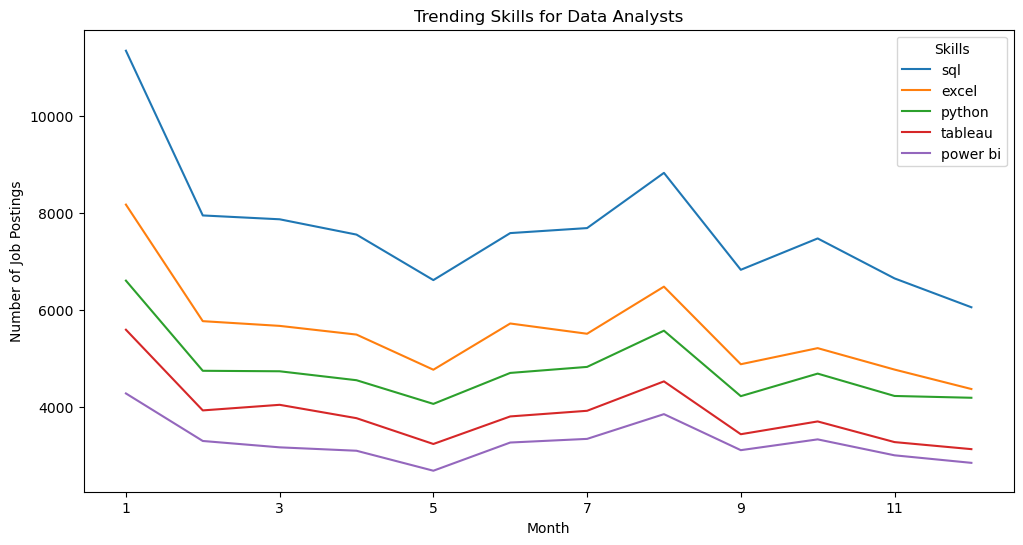

In [19]:
df_DA["job_posted_month_no"]=df_DA['job_posted_date'].dt.month
df_DA_exploded=df_DA.explode("job_skills")
df_DA_pivot=df_DA_exploded.pivot_table(index="job_posted_month_no", columns="job_skills", aggfunc="size", fill_value=0)
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
sortiing=df_DA_pivot.loc['Total'].sort_values(ascending=False).index
df_DA_pivot=df_DA_pivot[sortiing]
df_DA_pivot=df_DA_pivot.drop("Total")
df_DA_pivot.iloc[:,:5].plot(kind='line', figsize=(12,6))
plt.title("Trending Skills for Data Analysts")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.legend(title="Skills")
plt.show()

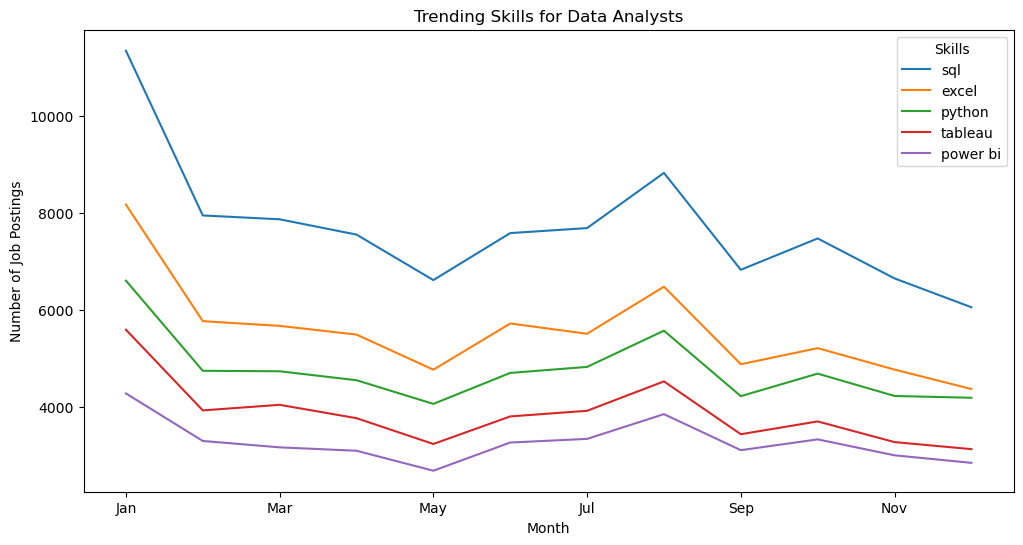

In [20]:
df_DA_pivot=df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month']=df_DA_pivot['job_posted_month_no'].apply(
    lambda x: pd.to_datetime (x, format='%m').strftime('%b'))
df_DA_pivot=df_DA_pivot.set_index('job_posted_month')
df_DA_pivot=df_DA_pivot.drop(columns='job_posted_month_no')

df_DA_pivot.iloc[:,:5].plot(kind='line', figsize=(12,6))
plt.title("Trending Skills for Data Analysts")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.legend(title="Skills")

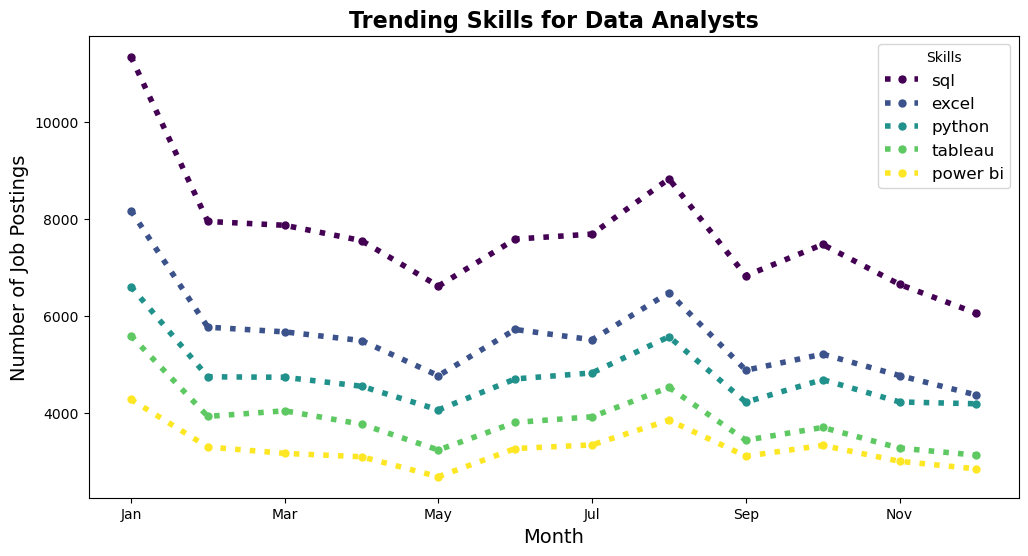

In [36]:
df_DA_pivot.iloc[:,:5].plot(
    kind='line',
    linewidth=4,
    linestyle=':',
    colormap='viridis',
    marker='o',
    markersize=5,
    figsize=(12,6))
plt.title("Trending Skills for Data Analysts", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Job Postings", fontsize=14)
plt.legend(title="Skills", fontsize=12)
plt.show()